In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_tangent_normal(x_func, y_func, t0, dt=1e-5):
    """
    Computes unit tangent and normal vectors for a parametric curve at t0.
    """
    # Numerical derivatives
    dx_dt = (x_func(t0 + dt) - x_func(t0 - dt)) / (2 * dt)
    dy_dt = (y_func(t0 + dt) - y_func(t0 - dt)) / (2 * dt)
    
    # Tangent vector
    tangent = np.array([dx_dt, dy_dt])
    tangent_norm = np.linalg.norm(tangent)
    
    if tangent_norm < 1e-10:
        return None, None, None
    
    tangent_unit = tangent / tangent_norm
    
    # Rotate tangent by +pi/2 to get normal (counterclockwise)
    normal_unit = np.array([-tangent_unit[1], tangent_unit[0]])
    
    # Point on the curve
    point = np.array([x_func(t0), y_func(t0)])
    
    return point, tangent_unit, normal_unit

def symmetry_set(x_func, y_func, tvals, lambda_max=50):
    """
    Compute symmetry set by detecting sign changes in the tangency condition.
    """
    centers = []
    threshold = 5 * (tvals[1] - tvals[0])
    
    for i, t1 in enumerate(tvals):
        result1 = compute_tangent_normal(x_func, y_func, t1)
        if result1[0] is None:
            continue
        p1, T1, N1 = result1
        
        # Store previous values for sign change detection
        prev_check1 = None
        prev_check2 = None
        prev_t2 = None
        
        for j, t2 in enumerate(tvals[i+1:], i+1):
            if abs(t2 - t1) < threshold:
                continue
            
            result2 = compute_tangent_normal(x_func, y_func, t2)
            if result2[0] is None:
                continue
            p2, T2, N2 = result2
            
            # Skip if tangents are parallel or anti-parallel
            if np.linalg.norm(T1-T2) < 1e-5 or np.linalg.norm(T1+T2) < 1e-5:
                prev_check1 = None
                prev_check2 = None
                continue
            
            # Compute tangency conditions
            eq_check1 = np.dot((p1-p2), (T1+T2))
            eq_check2 = np.dot((p1-p2), (T1-T2))
            
            # Check for sign changes
            if prev_check1 is not None:
                # Check if eq_check1 changed sign
                if prev_check1 * eq_check1 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check1) / (abs(prev_check1) + abs(eq_check1))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the sum formula for center calculation
                        Nsum = N1 + N_interp
                        denom = np.dot(Nsum, Nsum)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsum) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
                
                # Check if eq_check2 changed sign
                if prev_check2 * eq_check2 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check2) / (abs(prev_check2) + abs(eq_check2))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the difference formula for center calculation
                        Nsub = N1 - N_interp
                        denom = np.dot(Nsub, Nsub)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsub) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
            
            # Store current values for next iteration
            prev_check1 = eq_check1
            prev_check2 = eq_check2
            prev_t2 = t2
    
    return np.array(centers)

# Test with ellipse
a, b = 5, 3
x_func = lambda t: a * (2 * np.cos(t) - np.cos(2*t))
y_func = lambda t: a * (2 * np.sin(t) - np.sin(2*t))
t_vals = np.linspace(0, 2*np.pi, 500)

# Compute symmetry set
centers = symmetry_set(x_func, y_func, t_vals)

# Generate curve points
curve = np.array([np.array((x_func(t), y_func(t))) for t in t_vals])

# Plot
plt.figure(figsize=(10, 10))
plt.plot(curve[:,0], curve[:,1], 'b-', linewidth=2, label='Curve γ(t)')
if len(centers) > 0:
    plt.scatter(centers[:,0], centers[:,1], s=3, color='red', 
               alpha=0.6, label=f'Symmetry Set ({len(centers)} points)')
plt.axis('equal')
plt.legend()
plt.title("Symmetry Set")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

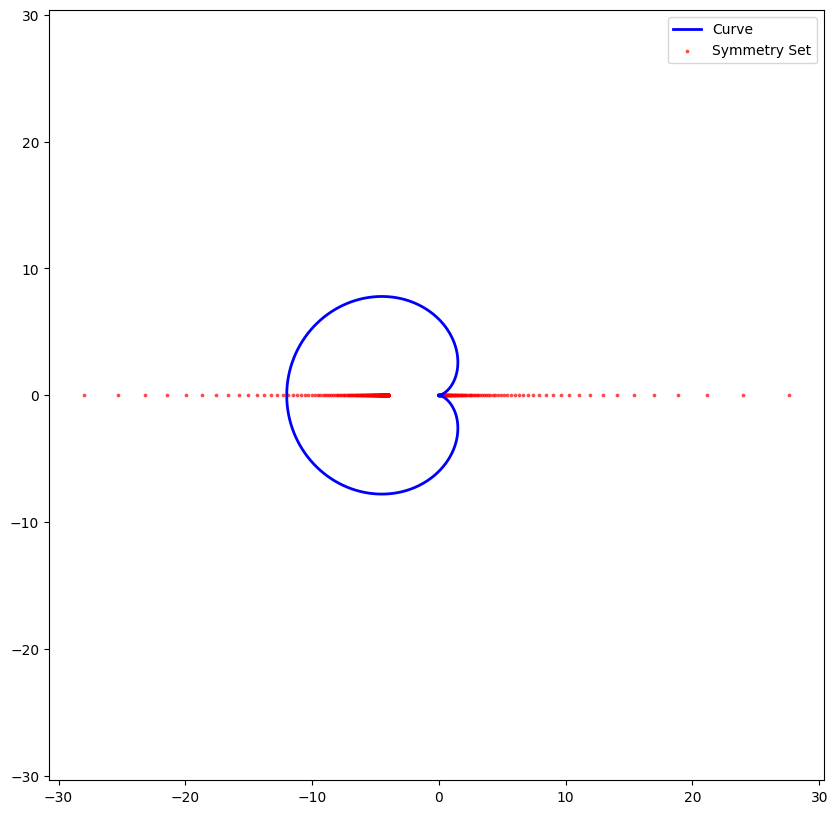

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('symmetry_set.csv')
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']

plt.figure(figsize=(10, 10))
plt.plot(curve['x'], curve['y'], 'b-', linewidth=2, label='Curve')
plt.scatter(symmetry['x'], symmetry['y'], s=3, color='red', alpha=0.6, label='Symmetry Set')
plt.axis('equal')
plt.legend()
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_parametric_curve(x_func, y_func, t_min, t_max, num_points=500, color='b', linewidth=2, label='Parametric Curve'):
    """
    Plots a 2D parametric curve given x(t) and y(t).

    Parameters:
        x_func, y_func : callable
            Functions defining the parametric curve, i.e. x = x(t), y = y(t)
        t_min, t_max : float
            Range of the parameter t
        num_points : int, optional
            Number of sample points (default 500)
        color : str, optional
            Curve color (default 'b')
        linewidth : float, optional
            Width of the curve line (default 2)
        label : str, optional
            Legend label for the curve (default 'Parametric Curve')
    """
    # Generate parameter values
    t_vals = np.linspace(t_min, t_max, num_points)
    
    # Evaluate x(t), y(t)
    x_vals = x_func(t_vals)
    y_vals = y_func(t_vals)

    # Plot
    plt.figure(figsize=(7,7))
    plt.plot(x_vals, y_vals, color=color, linewidth=linewidth, label=label)
    plt.xlabel("x(t)")
    plt.ylabel("y(t)")
    plt.title("2D Parametric Curve")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()


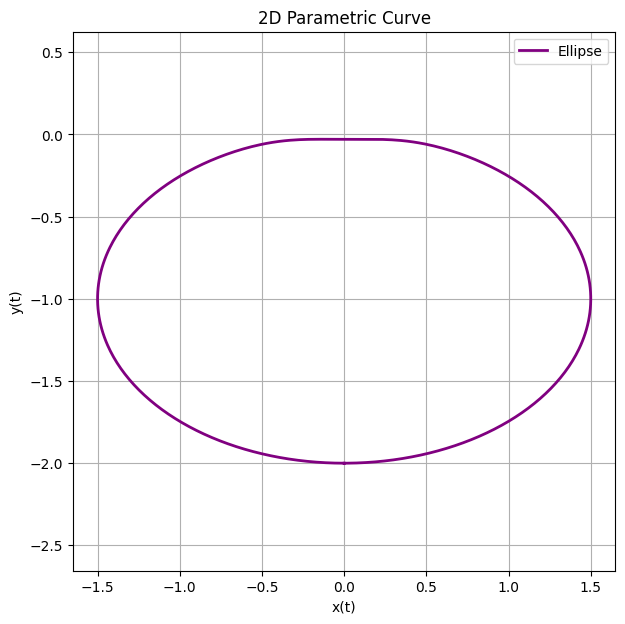

In [46]:
a, b = 1.5,1
H,q = 0.03,20
x_func = lambda t: a * np.sin(t)
y_func = lambda t: (b * (np.cos(t)-1)) - (H * np.exp(-np.longdouble(q)*(np.longdouble(t)**2)))

plot_parametric_curve(x_func, y_func, -np.pi,np.pi, color='purple', label='Ellipse')

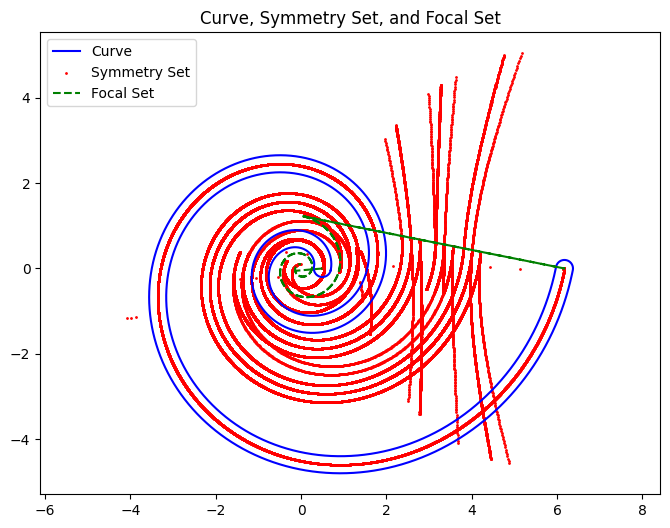

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("analysis_output.csv")

# Separate points
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']
focal = df[df['type'] == 'focal']

plt.figure(figsize=(8,6))

# Curve as solid blue
plt.plot(curve['x'], curve['y'], 'b-', label='Curve')

# Symmetry points as red dots
plt.scatter(symmetry['x'], symmetry['y'], c='r', s=10, label='Symmetry Set')

# Focal set as dashed green line
plt.plot(focal['x'], focal['y'], 'g--', label='Focal Set')

plt.axis('equal')
plt.legend()
plt.title("Curve, Symmetry Set, and Focal Set")
plt.show()


## Persistence tracking

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os

# 1. Load Data
potato_df = pd.read_csv('potato.csv')
circle_points_df = pd.read_csv('potato_circle_points.csv')

# 2. Extract curve points
curve_points_df = potato_df[potato_df['type'] == 'curve'].copy()
potato_coords = curve_points_df[['x', 'y']].values

# 3. Check if closed
start_node = potato_coords[0]
end_node = potato_coords[-1]
dist_ends = np.linalg.norm(start_node - end_node)
# Heuristic: if distance is small relative to the extent of the shape, it's closed.
# Let's say < 1% of max extent.
extent = np.max(potato_coords.max(axis=0) - potato_coords.min(axis=0))
is_closed = dist_ends < (0.02 * extent)
print(f"Start: {start_node}, End: {end_node}, Dist: {dist_ends}, Extent: {extent}")
print(f"Curve is considered closed: {is_closed}")

# 4. Setup Center and Distances
center_point = circle_points_df.iloc[0]
center_x, center_y = center_point['X'], center_point['Y']
dists = np.sqrt((potato_coords[:, 0] - center_x)**2 + (potato_coords[:, 1] - center_y)**2)
max_dist = np.max(dists)

# 5. Counting Function
def count_green_segments(mask, is_closed):
    if not np.any(mask):
        return 0
    if np.all(mask):
        return 1 # All one big component

    # Find transitions
    # Pad with False at both ends to detect start/end easily for linear case
    padded = np.concatenate(([False], mask, [False]))
    changes = np.diff(padded.astype(int))
    starts = np.where(changes == 1)[0]
    count = len(starts)
    
    if is_closed:
        # If closed, check if the first and last points are both True.
        # If so, the first segment and last segment are actually the same one.
        if mask[0] and mask[-1]:
            count -= 1
            
    return count

# 6. Iterate and Generate
# Use more frames for smoother counting transition visualization
num_frames = 500
radii = np.linspace(0, max_dist * 1.1, num_frames)

counts = []
filenames = []

# Plot limits
x_min, x_max = curve_points_df['x'].min(), curve_points_df['x'].max()
y_min, y_max = curve_points_df['y'].min(), curve_points_df['y'].max()
padding = 0.1 * max(x_max - x_min, y_max - y_min)
x_lims = (x_min - padding, x_max + padding)
y_lims = (y_min - padding, y_max + padding)

for i, r in enumerate(radii):
    mask = dists <= r
    count = count_green_segments(mask, is_closed)
    counts.append(count)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Points
    ax.scatter(potato_coords[~mask, 0], potato_coords[~mask, 1], c='blue', s=5, label='Outside')
    ax.scatter(potato_coords[mask, 0], potato_coords[mask, 1], c='green', s=5, label='Inside')
    ax.plot(center_x, center_y, 'ro', markersize=8, label='Center')
    
    # Circle
    circle = plt.Circle((center_x, center_y), r, color='red', fill=False, linewidth=2)
    ax.add_patch(circle)
    
    # Styling
    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-1,1)
    ax.set_title(f'Radius: {r:.4f}\nGreen Components: {count}')
    
    # Save
    filename = f'frame_count_{i}.png'
    fig.savefig(filename)
    filenames.append(filename)
    plt.close(fig)

# Save GIF
gif_filename = 'potato_count_animation.gif'
with imageio.get_writer(gif_filename, mode='I', duration=0.15) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# Cleanup frames
for filename in filenames:
    if os.path.exists(filename):
        os.remove(filename)

Start: [0. 0.], End: [0. 0.], Dist: 0.0, Extent: 1.2789231738410787
Curve is considered closed: True


/tmp/ipykernel_45491/3184546073.py:101: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


In [17]:
import pandas as pd
import numpy as np

# 1. Load Data
potato_df = pd.read_csv('potato.csv')
circle_points_df = pd.read_csv('potato_circle_points.csv')

# 2. Extract curve points and center
curve_points_df = potato_df[potato_df['type'] == 'curve'].copy()
potato_coords = curve_points_df[['x', 'y']].values
center_point = circle_points_df.iloc[0]
center_x, center_y = center_point['X'], center_point['Y']

# 3. Calculate distances
dists = np.sqrt((potato_coords[:, 0] - center_x)**2 + (potato_coords[:, 1] - center_y)**2)
max_dist = np.max(dists)
num_points = len(dists)

# 4. Union-Find Data Structure with Birth Times
class UnionFind:
    def __init__(self, n, birth_values):
        self.parent = list(range(n))
        self.birth = birth_values[:] # Store birth times for each component (index is root)
        
    def find(self, i):
        if self.parent[i] != i:
            self.parent[i] = self.find(self.parent[i])
        return self.parent[i]
    
    def union(self, i, j, current_value):
        root_i = self.find(i)
        root_j = self.find(j)
        
        if root_i != root_j:
            # Merge components
            # Elder rule: keep the one with smaller birth time
            # If birth times are equal, just pick one (stable)
            if self.birth[root_i] < self.birth[root_j]:
                elder = root_i
                younger = root_j
            else:
                elder = root_j
                younger = root_i
            
            # Record death of younger
            death_value = current_value
            persistence_pair = (self.birth[younger], death_value)
            
            # Perform union
            self.parent[younger] = elder
            # The elder's birth time remains the same
            
            return persistence_pair, False # False = H0 merge
        else:
            # Cycle formed (loop closed)
            # H1 birth
            return (current_value, None), True # True = H1 birth

# 5. Filtration Algorithm
# Vertices sorted by distance
sorted_indices = np.argsort(dists)

uf = UnionFind(num_points, dists)
h0_pairs = []
h1_pairs = []

# To handle the graph structure:
# Each point i is connected to (i-1)%N and (i+1)%N
# We process vertices in sorted order.
# When vertex v enters, we check its neighbors.
# If a neighbor u is already in the filtration (dist[u] < dist[v] or (dist[u]==dist[v] and u processed)),
# then we effectively add edge (u, v).

processed = np.full(num_points, False)

for idx in sorted_indices:
    v = idx
    current_r = dists[v]
    processed[v] = True
    
    # Neighbors in the loop
    neighbors = [(v - 1) % num_points, (v + 1) % num_points]
    
    for u in neighbors:
        if processed[u]:
            # u is already in. This edge (u, v) now exists.
            # Attempt to union sets of u and v
            pair, is_h1 = uf.union(u, v, current_r)
            
            if is_h1:
                h1_pairs.append((pair[0], max_dist)) # Death is max_radius
            else:
                # Only store if persistence > 0 (ignore trivial pairs where birth==death)
                if pair[0] != pair[1]:
                    h0_pairs.append(pair)

# 6. Identify the Infinite H0 component
# The component that never died is the root of the final set.
# Its birth time is the global minimum.
root = uf.find(0) # Pick any point, find its root
global_min_birth = uf.birth[root]
h0_pairs.append((global_min_birth, max_dist))

# 7. Formatting and Output
print("Raw H0 Pairs:", h0_pairs)
print("Raw H1 Pairs:", h1_pairs)

# Filter noise? 
# Let's define a small threshold, or just look at top features.
# Given the "0->1->2->1" observation, we expect 1 finite H0 pair.
# Let's sort by persistence (lifetime).

h0_pairs_sorted = sorted(h0_pairs, key=lambda x: x[1] - x[0] if x[1] != max_dist else 999999, reverse=True)
h1_pairs_sorted = sorted(h1_pairs, key=lambda x: x[1] - x[0] if x[1] != max_dist else 999999, reverse=True)

print("\n--- Persistence Diagram ---")
print("H_0:")
for b, d in h0_pairs_sorted:
    if d == max_dist:
        d_str = "max_radius"
    else:
        d_str = f"{d:.4f}"
    print(f"{b:.4f},{d_str}")

print("H_1:")
for b, d in h1_pairs_sorted:
    if d == max_dist:
        d_str = "max_radius"
    else:
        d_str = f"{d:.4f}"
    print(f"{b:.4f},{d_str}")

Raw H0 Pairs: [(np.float64(0.626524574012806), np.float64(0.6405156867329378)), (np.float64(0.35986251833164323), np.float64(0.6794506656629418))]
Raw H1 Pairs: [(np.float64(0.6794506656629418), np.float64(0.6794506656629418))]

--- Persistence Diagram ---
H_0:
0.3599,max_radius
0.6265,0.6405
H_1:
0.6795,max_radius


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# 1. Setup
potato_df = pd.read_csv('potato.csv')
circle_points_df = pd.read_csv('potato_circle_points.csv')

curve_points_df = potato_df[potato_df['type'] == 'curve'].copy()
potato_coords = curve_points_df[['x', 'y']].values
centers = circle_points_df[['X', 'Y']].values

output_dir = 'persistence_diagrams_potato'
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# 2. Union-Find
class UnionFind:
    def __init__(self, n, birth_values):
        self.parent = list(range(n))
        self.birth = birth_values[:]
        
    def find(self, i):
        if self.parent[i] != i:
            self.parent[i] = self.find(self.parent[i])
        return self.parent[i]
    
    def union(self, i, j, current_value):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.birth[root_i] < self.birth[root_j]:
                elder, younger = root_i, root_j
            elif self.birth[root_j] < self.birth[root_i]:
                elder, younger = root_j, root_i
            else:
                elder, younger = (root_i, root_j) if root_i < root_j else (root_j, root_i)
            
            death_value = current_value
            persistence_pair = (self.birth[younger], death_value)
            self.parent[younger] = elder
            return persistence_pair, False
        else:
            return (current_value, None), True

# 3. Compute Persistence
def compute_persistence(center, coords):
    dists = np.sqrt(np.sum((coords - center)**2, axis=1))
    sorted_indices = np.argsort(dists)
    
    uf = UnionFind(len(coords), dists)
    h0_pairs = []
    h1_pairs = [] # (birth, death) where death is float or np.inf
    processed = np.full(len(coords), False)
    
    for v in sorted_indices:
        current_r = dists[v]
        processed[v] = True
        neighbors = [(v - 1) % len(coords), (v + 1) % len(coords)]
        
        for u in neighbors:
            if processed[u]:
                pair, is_h1 = uf.union(u, v, current_r)
                if is_h1:
                    h1_pairs.append((current_r, np.inf))
                else:
                    if pair[0] != pair[1]:
                        h0_pairs.append(pair)
    
    root = uf.find(0)
    h0_pairs.append((uf.birth[root], np.inf))
    return h0_pairs, h1_pairs

# 4. Processing Loop
# Find global max for plotting consistency
global_max_finite = 0
for center in centers:
    d = np.max(np.sqrt(np.sum((potato_coords - center)**2, axis=1)))
    if d > global_max_finite:
        global_max_finite = d

# Define Plot constants
infinity_y = global_max_finite * 1.1
plot_max = global_max_finite * 1.2

for i, center in enumerate(centers):
    h0, h1 = compute_persistence(center, potato_coords)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Draw diagonal
    ax.plot([0, plot_max], [0, plot_max], c='grey', linestyle='--', alpha=0.5)
    
    # Draw Infinity Line
    ax.axhline(y=infinity_y, color='k', linestyle=':', alpha=0.5)
    ax.text(0, infinity_y + 0.01, r'$\infty$', fontsize=12, va='bottom')
    
    # Separate finite and infinite
    # H0
    for b, d in h0:
        if d == np.inf:
            ax.scatter([b], [infinity_y], c='red', marker='o')
        else:
            ax.scatter([b], [d], c='red', marker='o')
            
    # H1
    for b, d in h1:
        if d == np.inf:
            ax.scatter([b], [infinity_y], c='blue', marker='^')
        else:
            ax.scatter([b], [d], c='blue', marker='^')

    ax.set_xlim(0, plot_max)
    ax.set_ylim(0, plot_max)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(f"Persistence Diagram (Center {i})")
    
    # Manual Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='$H_0$'),
                       Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='$H_1$')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    filename = os.path.join(output_dir, f'pd_{i:03d}.png')
    plt.savefig(filename)
    plt.close(fig)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
import shutil

# 1. Load Data
potato_df = pd.read_csv('potato.csv')
circle_points_df = pd.read_csv('potato_circle_points.csv')

# Separate points by type for plotting
curve_coords = potato_df[potato_df['type'] == 'curve'][['x', 'y']].values
symmetry_coords = potato_df[potato_df['type'] == 'symmetry'][['x', 'y']].values
focal_coords = potato_df[potato_df['type'] == 'focal'][['x', 'y']].values
all_potato_coords = potato_df[['x', 'y']].values # For overall bounds

centers = circle_points_df[['X', 'Y']].values
num_points_curve = len(curve_coords)

# 2. Union-Find Class
class UnionFind:
    def __init__(self, n, birth_values):
        self.parent = list(range(n))
        self.birth = birth_values[:]
        
    def find(self, i):
        path = []
        while self.parent[i] != i:
            path.append(i)
            i = self.parent[i]
        for node in path:
            self.parent[node] = i
        return i
    
    def union(self, i, j, current_value):
        root_i = self.find(i)
        root_j = self.find(j)
        
        if root_i != root_j:
            # Elder Rule
            if self.birth[root_i] < self.birth[root_j]:
                elder, younger = root_i, root_j
            elif self.birth[root_j] < self.birth[root_i]:
                elder, younger = root_j, root_i
            else:
                elder, younger = (root_i, root_j) if root_i < root_j else (root_j, root_i)

            death_value = current_value
            persistence_pair = (self.birth[younger], death_value)
            self.parent[younger] = elder
            return persistence_pair, False
        else:
            return (current_value, None), True

# 3. Compute Persistence Function
def compute_persistence(center, coords):
    dists = np.sqrt(np.sum((coords - center)**2, axis=1))
    sorted_indices = np.argsort(dists)
    
    uf = UnionFind(len(coords), dists)
    h0_pairs = []
    h1_pairs = []
    processed = np.full(len(coords), False)
    
    for v in sorted_indices:
        current_r = dists[v]
        processed[v] = True
        neighbors = [(v - 1) % len(coords), (v + 1) % len(coords)]
        
        for u in neighbors:
            if processed[u]:
                pair, is_h1 = uf.union(u, v, current_r)
                if is_h1:
                    h1_pairs.append((current_r, np.inf)) # H1 always ends at inf for 1D curve
                else:
                    if pair[0] != pair[1]: # Only add non-trivial pairs
                        h0_pairs.append(pair)
    
    root = uf.find(0)
    h0_pairs.append((uf.birth[root], np.inf)) # Infinite H0 component
    
    return h0_pairs, h1_pairs

# 4. Determine Global Plot Limits for Persistence Diagram
# Using the previously calculated global_max_finite from before or a new estimate
global_max_finite = np.max([np.max(np.sqrt(np.sum((curve_coords - c)**2, axis=1))) for c in centers])
infinity_y = global_max_finite * 1.1
plot_max_pd = global_max_finite * 1.2

# 5. Animation Loop
frames_dir = 'animation_frames'
if os.path.exists(frames_dir):
    shutil.rmtree(frames_dir) # Clear previous frames if any
os.makedirs(frames_dir)

for i, current_center in enumerate(centers):
    h0, h1 = compute_persistence(current_center, curve_coords)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # Two subplots side-by-side

    # --- Left Subplot: Potato Plot ---
    ax_potato = axes[0]
    
    # Plot curve points
    # ax_potato.scatter(curve_coords[:, 0], curve_coords[:, 1], c='gray', s=5, label='Curve')
    # Plot symmetry points
    ax_potato.scatter(symmetry_coords[:, 0], symmetry_coords[:, 1], c='red', s=1, label='Symmetry')
    # Plot focal points
    ax_potato.scatter(focal_coords[:, 0], focal_coords[:, 1], c='green', s=1, label='Focal')
    
    # Plot all circle points
    ax_potato.scatter(centers[:, 0], centers[:, 1], c='orange', s=3, alpha=0.5, label='All Centers')
    
    # Highlight current center
    ax_potato.scatter(current_center[0], current_center[1], c='blue', s=50, edgecolors='black', zorder=5, label='Current Center')
    
    ax_potato.set_xlim(0.45, 0.75)
    ax_potato.set_ylim(-0.1, 0.1)
    ax_potato.set_title("Potato")
    ax_potato.set_xlabel("X")
    ax_potato.set_ylabel("Y")
    ax_potato.legend(loc='upper left', fontsize=8)
    ax_potato.set_aspect('equal', adjustable='box') # Maintain aspect ratio
    
    # --- Right Subplot: Persistence Diagram ---
    ax_pd = axes[1]
    
    # Draw diagonal
    ax_pd.plot([0, plot_max_pd], [0, plot_max_pd], c='grey', linestyle='--', alpha=0.5)
    
    # Draw Infinity Line
    ax_pd.axhline(y=infinity_y, color='k', linestyle=':', alpha=0.5)
    ax_pd.text(0, infinity_y + 0.01, r'$\infty$', fontsize=12, va='bottom')
    
    # Plot H0 (red circles)
    for b, d in h0:
        if d == np.inf:
            ax_pd.scatter([b], [infinity_y], c='red', marker='o')
        else:
            ax_pd.scatter([b], [d], c='red', marker='o')
            
    # Plot H1 (blue triangles)
    for b, d in h1:
        if d == np.inf:
            ax_pd.scatter([b], [infinity_y], c='blue', marker='^')
        else:
            ax_pd.scatter([b], [d], c='blue', marker='^')

    ax_pd.set_xlim(0, plot_max_pd)
    ax_pd.set_ylim(0, plot_max_pd)
    ax_pd.set_xlabel("Birth")
    ax_pd.set_ylabel("Death")
    ax_pd.set_title(f"Persistence Diagram (Center {i})")
    ax_pd.set_aspect('equal', adjustable='box') # Maintain aspect ratio

    # Manual Legend for PD
    from matplotlib.lines import Line2D
    legend_elements_pd = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='$H_0$'),
                          Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='$H_1$')]
    ax_pd.legend(handles=legend_elements_pd, loc='lower right')
    
    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    frame_filename = os.path.join(frames_dir, f'viz_frame_{i:03d}.png')
    plt.savefig(frame_filename)
    plt.close(fig)
    
    if i % 20 == 0:
        print(f"Generated frame {i}/{len(centers)}")

# 6. Create GIF
gif_filename = 'center_pd_visualization.gif'
with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
    for filename in sorted(os.listdir(frames_dir)):
        if filename.endswith('.png'):
            image_path = os.path.join(frames_dir, filename)
            image = imageio.imread(image_path)
            writer.append_data(image)

# 7. Cleanup
shutil.rmtree(frames_dir)

print(f"Animation created: {gif_filename}")

Generated frame 0/200
Generated frame 20/200
Generated frame 40/200
Generated frame 60/200
Generated frame 80/200
Generated frame 100/200
Generated frame 120/200
Generated frame 140/200
Generated frame 160/200
Generated frame 180/200


/tmp/ipykernel_45491/3045054738.py:177: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_path)


Animation created: center_pd_visualization.gif


In [ ]:
data_records = []

for i, center in enumerate(centers):
    h0, h1 = compute_persistence(center, potato_coords)
    
    # H0
    for b, d in h0:
        death_val = d if d != np.inf else infinity_y
        data_records.append({
            'birth': b,
            'death': death_val,
            'center_index': i,
            'dimension': 0
        })
        
    # H1
    for b, d in h1:
        death_val = d if d != np.inf else infinity_y
        data_records.append({
            'birth': b,
            'death': death_val,
            'center_index': i,
            'dimension': 1
        })

# 6. Save to CSV
output_df = pd.DataFrame(data_records)
output_csv_name = 'persistence_data.csv'
output_df.to_csv(output_csv_name, index=False)

print(f"Data saved to {output_csv_name}")
print(f"Infinity value used: {infinity_y}")

Data saved to persistence_data.csv
Infinity value used: 0.7586519487886444


## Offset Spiral

Success! Generated 31000 points.
File saved as: spiral_points.csv


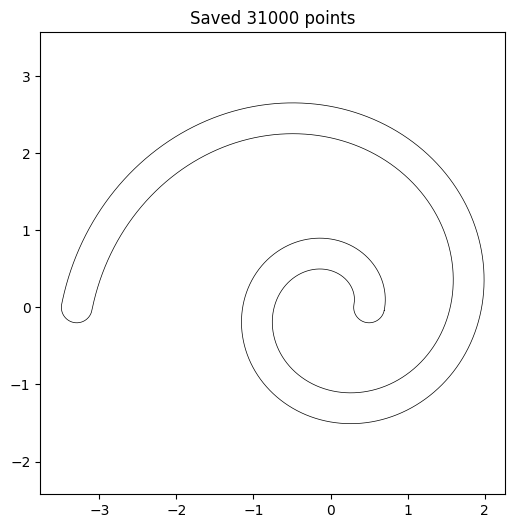

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_and_save_spiral():
    a = 0.5          # Start radius
    b = 0.2         # Growth rate
    width = 0.4      # Thickness
    theta_start = 0
    theta_end = 3 * np.pi
    
    resolution = 15000 

    theta = np.linspace(theta_start, theta_end, resolution)
    r = a * np.exp(b * theta)
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    dx_dt = r * (b * np.cos(theta) - np.sin(theta))
    dy_dt = r * (b * np.sin(theta) + np.cos(theta))
    
    mag = np.sqrt(dx_dt**2 + dy_dt**2)
    nx = -dy_dt / mag
    ny = dx_dt / mag

    half_w = width / 2
    
    # Outer Wall
    x_outer = x + nx * half_w
    y_outer = y + ny * half_w
    
    # Inner Wall
    x_inner = x - nx * half_w
    y_inner = y - ny * half_w

    # circular cap
    def create_cap(idx, is_start):
        ang_n = np.arctan2(ny[idx], nx[idx])
        if is_start:
            angles = np.linspace(ang_n + np.pi, ang_n, 500)
        else:
            angles = np.linspace(ang_n, ang_n - np.pi, 500)
        
        cap_x = x[idx] + half_w * np.cos(angles)
        cap_y = y[idx] + half_w * np.sin(angles)
        return cap_x, cap_y

    cap_start_x, cap_start_y = create_cap(0, is_start=True)
    cap_end_x, cap_end_y = create_cap(-1, is_start=False)

    final_x = np.concatenate([cap_start_x, x_outer, cap_end_x, x_inner[::-1]])
    final_y = np.concatenate([cap_start_y, y_outer, cap_end_y, y_inner[::-1]])

    df = pd.DataFrame({
        'x': final_x,
        'y': final_y
    })
    
    # Save file
    filename = 'spiral_points.csv'
    df.to_csv(filename, index=False)
    
    print(f"Success! Generated {len(df)} points.")
    print(f"File saved as: {filename}")

    # --- Optional: Quick Plot to Verify ---
    plt.figure(figsize=(6,6))
    plt.plot(final_x, final_y, 'k-', linewidth=0.5)
    plt.title(f"Saved {len(df)} points")
    plt.axis('equal')
    plt.show()

# Run the function
generate_and_save_spiral()

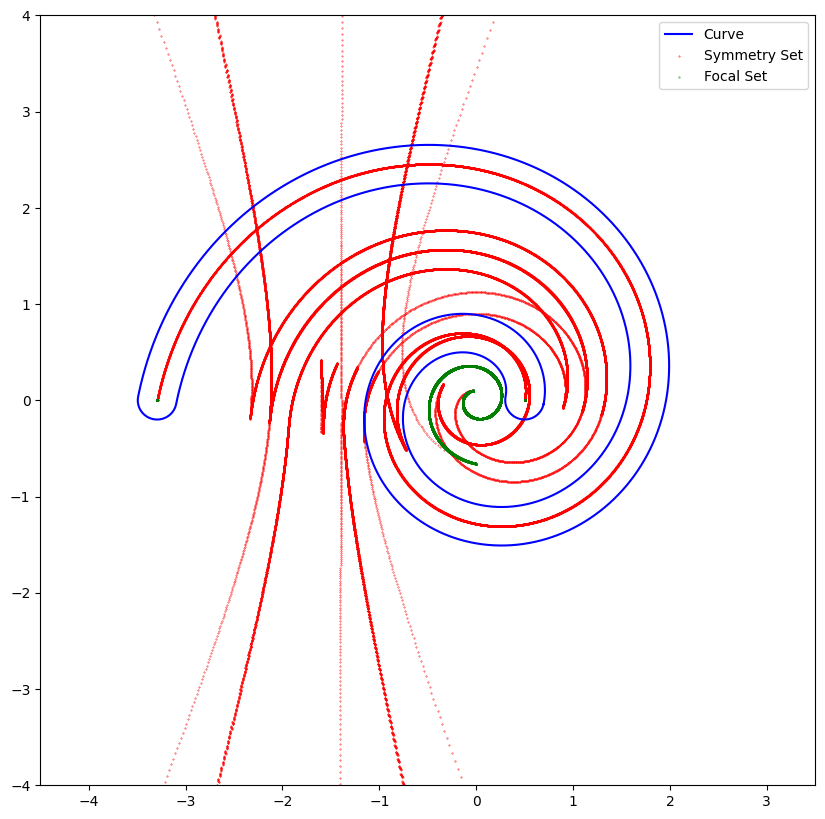

In [ ]:
# Load CSV
df = pd.read_csv("generic_spiral_sf.csv")
curve_df = pd.read_csv("generic_spiral_points.csv")
# Separate points
curve = curve_df[1::]
symmetry = df[df['type'] == 'symmetry']
focal = df[df['type'] == 'focal']

plt.figure(figsize=(10,10))

# Curve as solid blue
plt.plot(curve['x'], curve['y'], 'b-', label='Curve')

# Symmetry points as red dots
plt.scatter(symmetry['x'], symmetry['y'], c='r', s=0.1, label='Symmetry Set')

# Focal set as dashed green line
plt.scatter(focal['x'], focal['y'], c='g', s=0.1, label='Focal Set')

# Set axis ranges
plt.xlim(-4.5, 3.5)
plt.ylim(-4, 4)

# plt.axis('auto')
plt.legend()
plt.show()
